In [21]:
# TODO 1: import yfinance, numpy, matplotlib
# TODO 2: download SPY from 2020-01-01, auto_adjust=True, store in df
# TODO 3: print the first 5 rows and the shape
# TODO 4: make a column "ret" = daily % change of Close
# TODO 5: make a column "vol20" = 20-day rolling std of ret, annualized
# TODO 6: plot Close and vol20 as two stacked charts
# TODO 7: histogram of ret with 50 bins
# TODO 8: print the date with the highest vol20
# TODO 9: print the worst single-day return and its date
# TODO 10: Markdown cell with 3 things you noticed

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = yf.download("SPY", start="2020-01-01", end="2025-01-01", auto_adjust=True, multi_level_index= False)
assert df is not None, 'DOWNLOAD FAILED ARGHHH'
df.shape


[*********************100%***********************]  1 of 1 completed


(1258, 5)

data is formatted in a way which gives it two column labels
use multi_level_index = False in order to make it one label

,Close,High,Low,Open,Volume,ret,vol20
Date,,,,,,,
2020-01-02,295.391815,295.410018,293.264146,294.182509,59151200,NaN,NaN
2020-01-03,293.155029,294.273431,291.963899,292.018452,77709700,-0.007572,NaN
2020-01-06,294.273346,294.355176,291.290942,291.409151,55653900,0.003815,NaN
2020-01-07,293.445953,294.182453,293.000396,293.709619,40496400,-0.002812,NaN
2020-01-08,295.009918,296.219224,293.391434,293.636924,68296000,0.005330,NaN
...,...,...,...,...,...,...,...
2024-12-17,590.659058,591.519212,589.290673,590.561337,55773500,-0.004120,0.063848
2024-12-18,573.055359,592.731233,572.674142,590.356054,108248700,-0.029803,0.127071
2024-12-19,572.879456,579.623838,572.635095,578.020817,85919500,-0.000307,0.127048


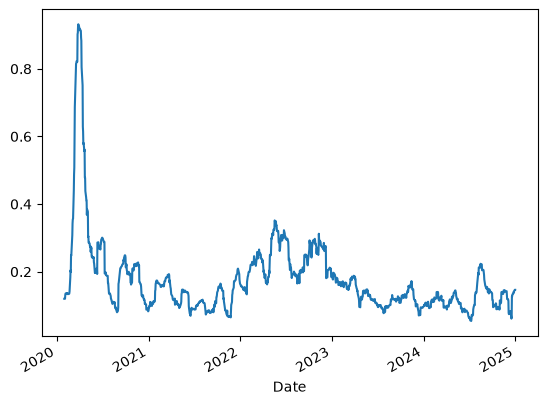

In [25]:
close = df['Close']

df['ret'] = close.pct_change()
df['vol20'] = df['ret'].rolling(20).std() * np.sqrt(252)
df['vol20'].plot()

df.head(-5)

df is a pandas dataframe
in close = df['Close'].squeeze() i took a column and then squeezed it into one column so that it becomes a pandas.Series type 
**REVISION:** .squeeze is not needed if i use multi_level_index = False

.pct_change computes the fractional change from the immediate row and the previous. or the **daily percent change** in price as a decimal.

.rolling(n) takes a window of n and then performs the operation on the n rows that you chain after. For example, .rolling(n).std()

multiplying by np.sqrt(252) normalizes the daily std we calced over 20 days into an annual std. if we want months we can use sqrt12 instead.

